# Momepy roads - Milan

This notebook uses momepy to calculate geometrical and topological features of the Milan street network:
- **Street profile**: `width`, `openness`, `width_deviation` (requires OSM buildings)
- **Betweenness centrality** (node-based, local radius 500 m, propagated to edges via mean_nodes)
- **Closeness centrality** -- extended local (radius 800 m) and local 400 m
- **Straightness centrality** (node-based, radius 500 m)

Input: `MIL_noise_streets.gpkg` -- the Milan OSM drive streets with acoustic zone noise classes.

Local-radius variants are used for tractability, matching the Berlin pipeline.

## Import libraries

In [3]:
import os
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Import streets segments

In [4]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
edges = gpd.read_file(os.path.join(_layers_dir, 'MIL_noise_streets.gpkg'))
print(edges.crs)
print(edges.shape)
print(edges.columns.tolist())
print('Number of street segments:', len(edges))

EPSG:32632
(22164, 12)
['segment_id', 'highway', 'name', 'length', 'CLASSE_ACU', 'db_diurno', 'db_notturno', 'noise_day', 'noise_evening', 'noise_night', 'distance', 'geometry']
Number of street segments: 22164


In [5]:
place_name = 'Milan, Italy'
tags = {'building': True}

print('Downloading buildings from OSM...')
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)

print(f'Downloaded {len(buildings)} buildings.')
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]
buildings = buildings.to_crs(edges.crs)
print(f'Polygon buildings: {len(buildings)}')

Downloaded 63637 buildings.
Polygon buildings: 63601


## Create Momepy street profile

In [6]:
profile = mm.street_profile(edges, buildings)
profile.head()

,width,openness,width_deviation
0,50.000000,1.000000,NaN
1,50.000000,1.000000,NaN
2,38.839167,0.915254,5.325141
3,50.000000,1.000000,NaN
4,50.000000,1.000000,NaN


In [7]:
edges[profile.columns] = profile
edges[profile.columns].head()

,width,openness,width_deviation
0,50.000000,1.000000,NaN
1,50.000000,1.000000,NaN
2,38.839167,0.915254,5.325141
3,50.000000,1.000000,NaN
4,50.000000,1.000000,NaN


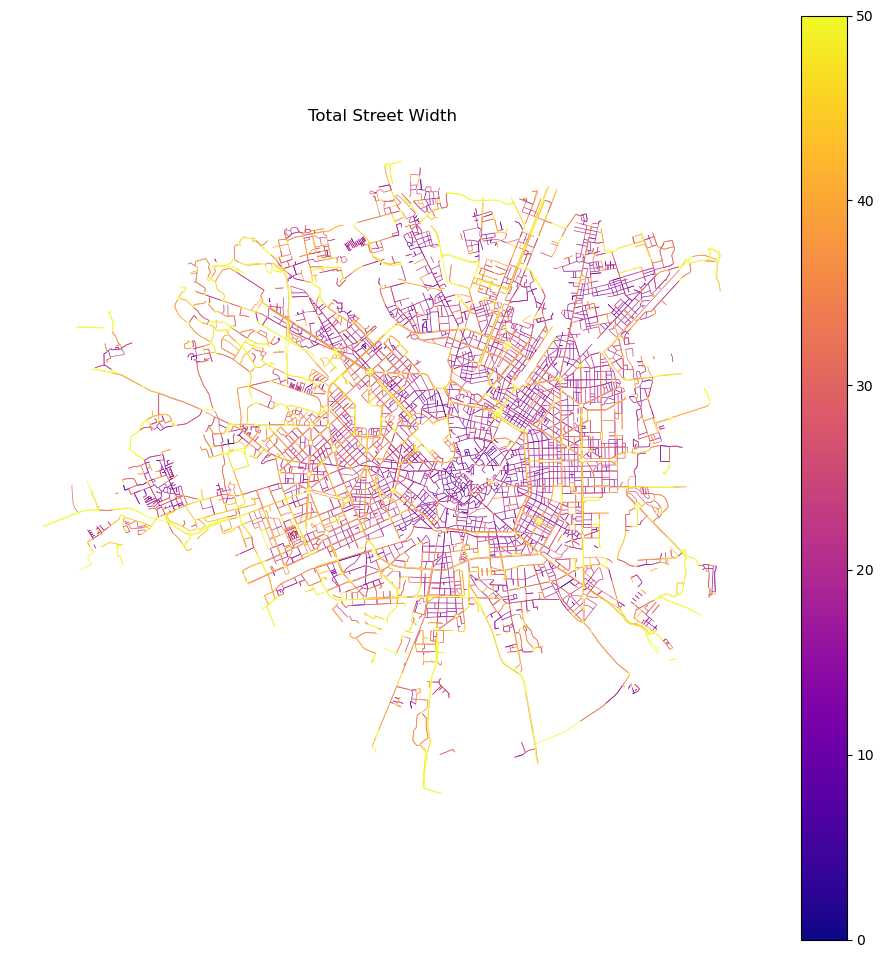

In [8]:
ax = edges.plot(cmap='plasma', column='width', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Total Street Width')
ax.set_axis_off()

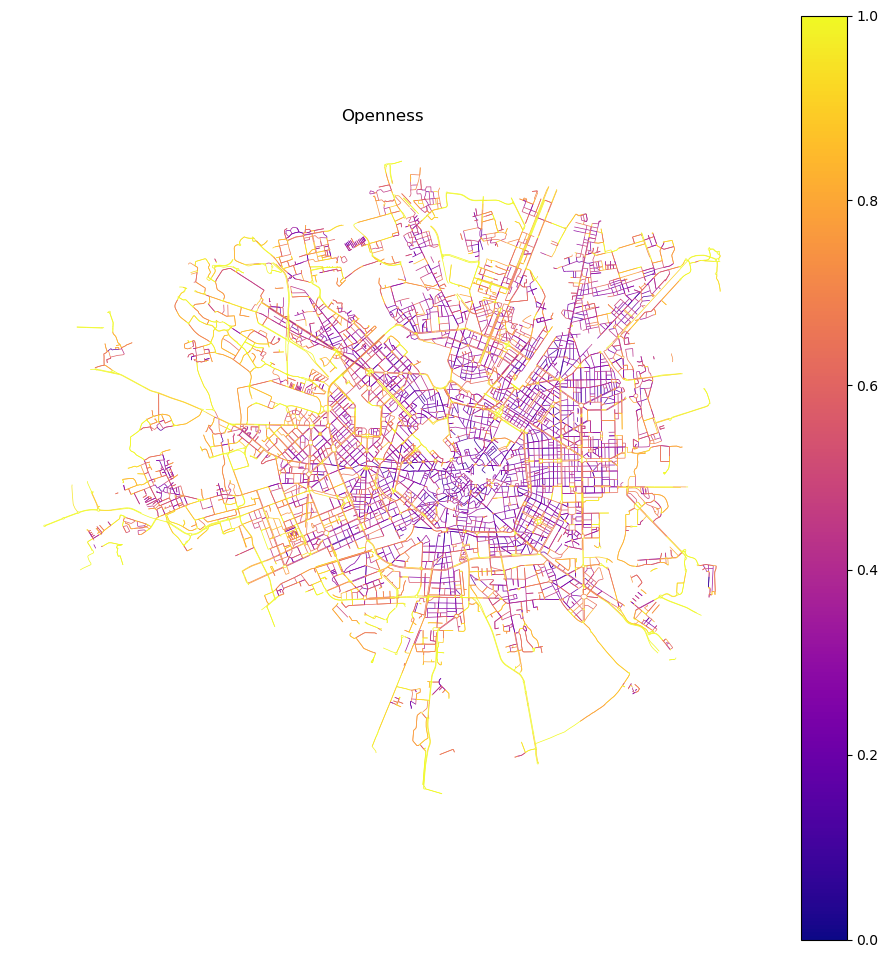

In [9]:
ax = edges.plot(cmap='plasma', column='openness', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Openness')
ax.set_axis_off()

# Centrality

Build the primal graph once; all centrality functions operate on it.

In momepy 0.11 all centralities are node-based. `mm.mean_nodes()` propagates each
node attribute to its incident edges (mean of the two endpoint values) before the
edge GeoDataFrame is extracted.

In [10]:
primal = mm.gdf_to_nx(edges, approach="primal")
print('Graph nodes:', primal.number_of_nodes(), '  edges:', primal.number_of_edges())

Graph nodes: 11948   edges: 22164


## Betweenness Centrality

In [11]:
betweenness = mm.betweenness_centrality(
    primal, name='betweenness_metric_e', mode='edges', weight='mm_len',
)

In [13]:
primal_gdf_betw = mm.nx_to_gdf(betweenness, points=False)
primal_gdf_betw.head()

,segment_id,highway,name,length,CLASSE_ACU,db_diurno,db_notturno,noise_day,noise_evening,noise_night,distance,geometry,width,openness,width_deviation,mm_len,betweenness_metric_e
0,10371529_743371634_0,primary,Via Novara,154.435012,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505987.753 5037117.669, 505836.365...",50.000000,1.000000,NaN,154.787234,1.640854e-04
1,10371529_743371622_0,tertiary,Via Novara,150.466270,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505987.753 5037117.669, 505947.376...",50.000000,1.000000,NaN,150.720611,6.358894e-03
2,267413392_10371529_0,primary,Via Novara,626.808902,4,65.0,55.0,3,3,2,0.0,"LINESTRING (506543.566 5036827.205, 506531.9 5...",44.776735,0.985294,0.006411,627.878261,6.685257e-03
3,743371634_267879825_0,primary,Via Novara,34.101035,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505836.365 5037149.933, 505803.085...",50.000000,1.000000,NaN,34.177859,1.120898e-06
4,743371634_743371622_0,tertiary,Via Novara,47.848772,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505836.365 5037149.933, 505846.964...",50.000000,1.000000,NaN,47.858919,1.681346e-07


Text(0.5, 1.0, 'Betweenness Centrality - Edge Mean (r=500 m)')

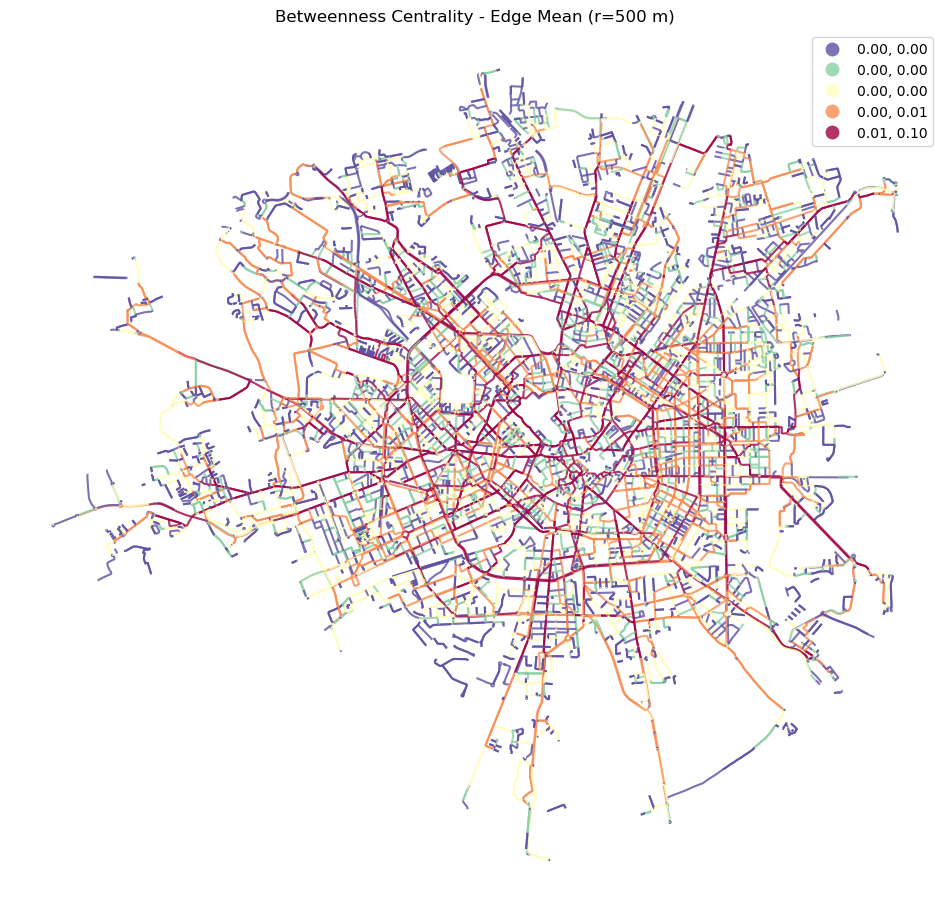

In [14]:
ax = primal_gdf_betw.plot(
    column='betweenness_metric_e',
    cmap='Spectral_r',
    scheme='quantiles',
    alpha=0.8,
    legend=True,
    figsize=(12, 12)
)
ax.set_axis_off()
ax.set_title('Betweenness Centrality - Edge Mean (r=500 m)')

## Global Closeness Centrality

Careful, takes a few minutes

In [ ]:
closeness = mm.closeness_centrality(
    primal, name='closeness_global', weight='mm_len'
)

  0%|          | 0/11948 [00:00<?, ?it/s]

In [ ]:
nodes = mm.nx_to_gdf(closeness, lines=False)
nodes.head()
nodes.info()

,segment_id,highway,name,length,CLASSE_ACU,db_diurno,db_notturno,noise_day,noise_evening,noise_night,distance,geometry,width,openness,width_deviation,mm_len,closeness_global
0,10371529_743371634_0,primary,Via Novara,154.435012,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505987.753 5037117.669, 505836.365...",50.000000,1.000000,NaN,154.787234,0.000005
1,10371529_743371622_0,tertiary,Via Novara,150.466270,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505987.753 5037117.669, 505947.376...",50.000000,1.000000,NaN,150.720611,0.000005
2,267413392_10371529_0,primary,Via Novara,626.808902,4,65.0,55.0,3,3,2,0.0,"LINESTRING (506543.566 5036827.205, 506531.9 5...",44.776735,0.985294,0.006411,627.878261,0.000003
3,743371634_267879825_0,primary,Via Novara,34.101035,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505836.365 5037149.933, 505803.085...",50.000000,1.000000,NaN,34.177859,0.000006
4,743371634_743371622_0,tertiary,Via Novara,47.848772,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505836.365 5037149.933, 505846.964...",50.000000,1.000000,NaN,47.858919,0.000006


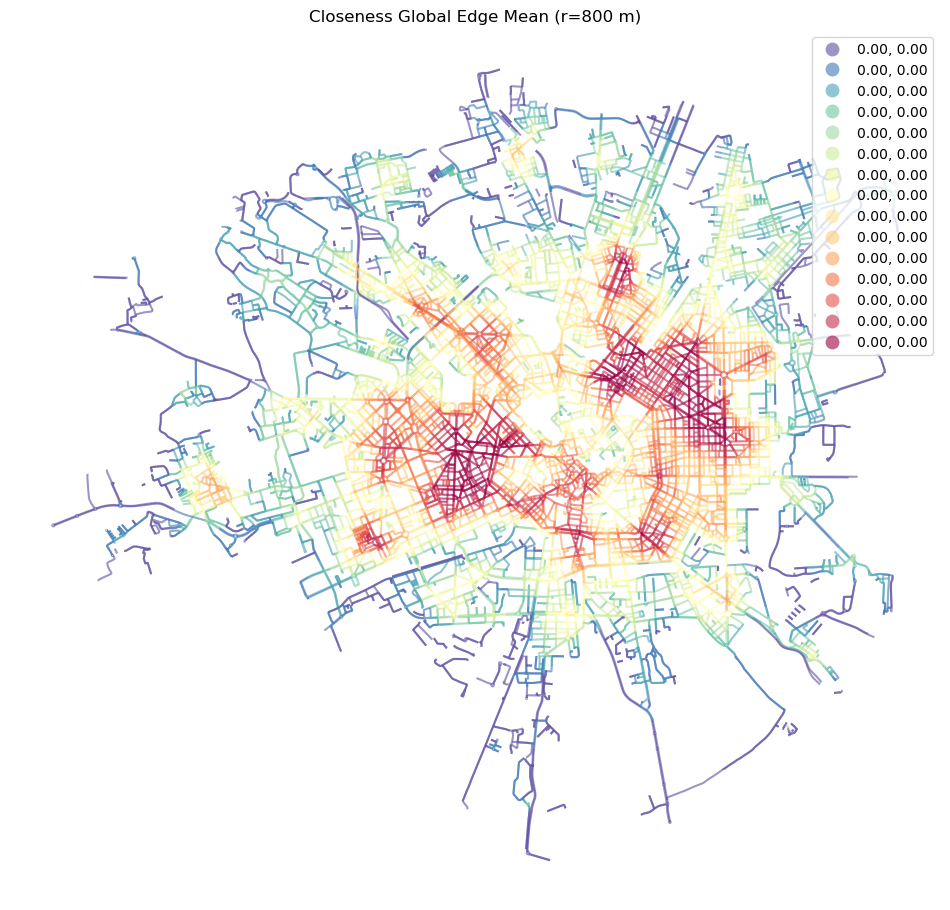

In [14]:
ax = primal_gdf_clos.plot(
    column='closeness_global',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
_ = ax.set_title('Closeness Global Edge Mean (r=800 m)')

## Local Closeness Centrality (radius 400 m)

In [15]:
local_clos = mm.closeness_centrality(
    primal, radius=400, name='closeness400', distance='mm_len', weight='mm_len'
)

  0%|          | 0/11948 [00:00<?, ?it/s]

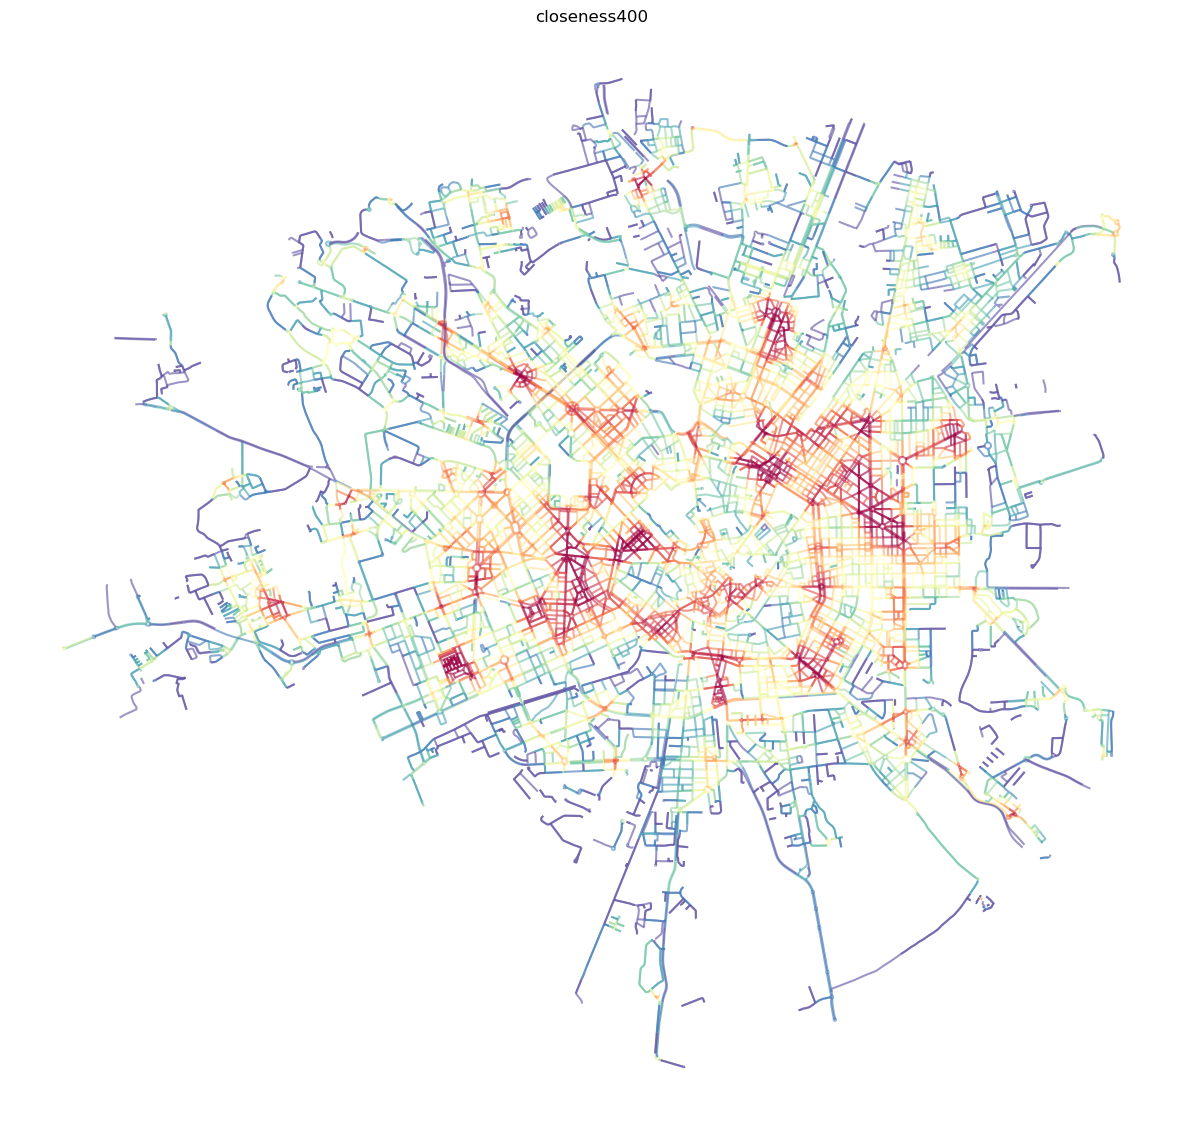

In [16]:
mm.mean_nodes(local_clos, 'closeness400')
local_clos_gdf = mm.nx_to_gdf(local_clos, points=False)

ax = local_clos_gdf.plot(
    column='closeness400',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title('closeness400')

## Straightness (node-based, radius 500 m)

In [17]:
straighteness = mm.straightness_centrality(
    primal, radius=500, distance='mm_len'
)

  0%|          | 0/11948 [00:00<?, ?it/s]

In [18]:
mm.mean_nodes(straighteness, 'straightness')
primal_gdf_straight = mm.nx_to_gdf(straighteness, points=False)
primal_gdf_straight.head()

,segment_id,highway,name,length,CLASSE_ACU,db_diurno,db_notturno,noise_day,noise_evening,noise_night,distance,geometry,width,openness,width_deviation,mm_len,straightness
0,10371529_743371634_0,primary,Via Novara,154.435012,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505987.753 5037117.669, 505836.365...",50.000000,1.000000,NaN,154.787234,0.950607
1,10371529_743371622_0,tertiary,Via Novara,150.466270,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505987.753 5037117.669, 505947.376...",50.000000,1.000000,NaN,150.720611,0.937863
2,267413392_10371529_0,primary,Via Novara,626.808902,4,65.0,55.0,3,3,2,0.0,"LINESTRING (506543.566 5036827.205, 506531.9 5...",44.776735,0.985294,0.006411,627.878261,0.983097
3,743371634_267879825_0,primary,Via Novara,34.101035,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505836.365 5037149.933, 505803.085...",50.000000,1.000000,NaN,34.177859,0.931829
4,743371634_743371622_0,tertiary,Via Novara,47.848772,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505836.365 5037149.933, 505846.964...",50.000000,1.000000,NaN,47.858919,0.909429


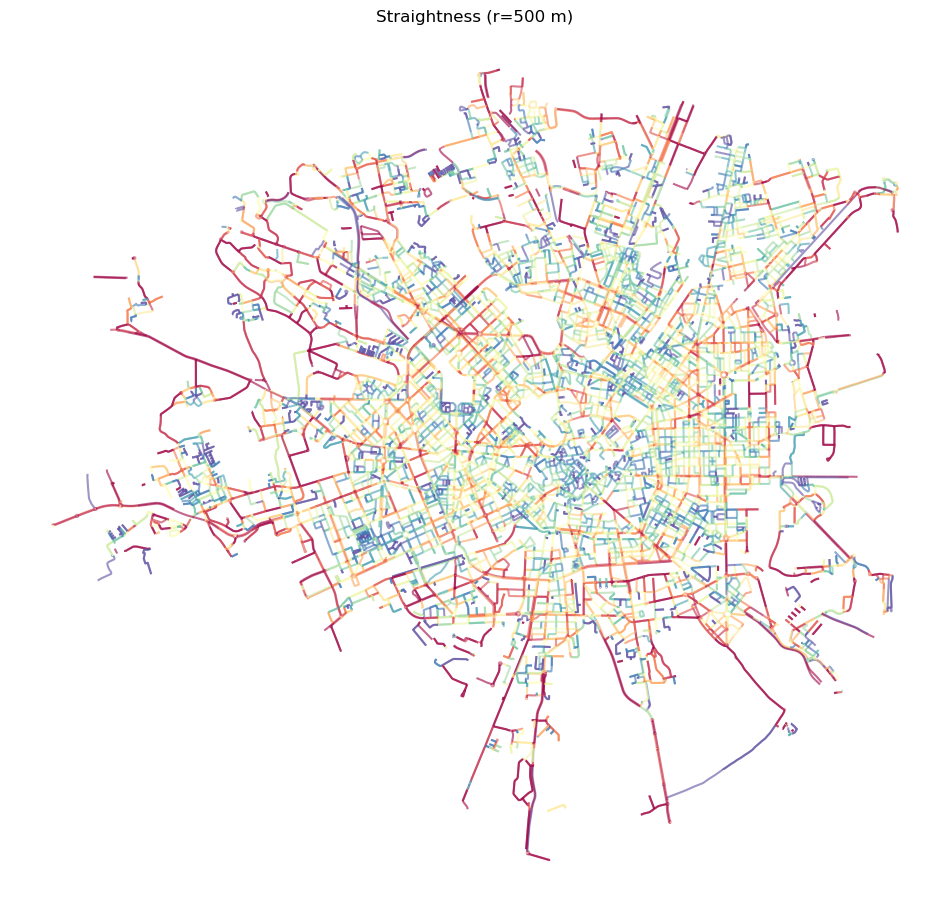

In [19]:
ax = primal_gdf_straight.plot(
    column='straightness',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
_ = ax.set_title('Straightness (r=500 m)')

## Merge all centrality features

Combine width/openness (from street profile), betweenness, closeness and straightness
into a single edge GeoDataFrame keyed by `segment_id`.

In [20]:
# primal_gdf_straight carries width, openness and other profile columns because
# mm.gdf_to_nx preserves all edge attributes from the input GDF
primal_gdf = primal_gdf_straight.copy()

def _safe_merge(base, other, col):
    if 'segment_id' in other.columns and 'segment_id' in base.columns:
        return base.merge(other[['segment_id', col]], on='segment_id', how='left')
    base = base.copy()
    base[col] = other[col].values
    return base

primal_gdf = _safe_merge(primal_gdf, primal_gdf_betw, 'betweenness_metric_e')
primal_gdf = _safe_merge(primal_gdf, primal_gdf_clos, 'closeness_global')
primal_gdf = _safe_merge(primal_gdf, local_clos_gdf, 'closeness400')

print(primal_gdf.columns.tolist())
primal_gdf.head()

['segment_id', 'highway', 'name', 'length', 'CLASSE_ACU', 'db_diurno', 'db_notturno', 'noise_day', 'noise_evening', 'noise_night', 'distance', 'geometry', 'width', 'openness', 'width_deviation', 'mm_len', 'straightness', 'betweenness_metric_e', 'closeness_global', 'closeness400']


,segment_id,highway,name,length,CLASSE_ACU,db_diurno,db_notturno,noise_day,noise_evening,noise_night,distance,geometry,width,openness,width_deviation,mm_len,straightness,betweenness_metric_e,closeness_global,closeness400
0,10371529_743371634_0,primary,Via Novara,154.435012,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505987.753 5037117.669, 505836.365...",50.000000,1.000000,NaN,154.787234,0.950607,8.5,0.000005,0.000007
1,10371529_743371622_0,tertiary,Via Novara,150.466270,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505987.753 5037117.669, 505947.376...",50.000000,1.000000,NaN,150.720611,0.937863,3.0,0.000005,0.000007
2,267413392_10371529_0,primary,Via Novara,626.808902,4,65.0,55.0,3,3,2,0.0,"LINESTRING (506543.566 5036827.205, 506531.9 5...",44.776735,0.985294,0.006411,627.878261,0.983097,0.0,0.000003,0.000003
3,743371634_267879825_0,primary,Via Novara,34.101035,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505836.365 5037149.933, 505803.085...",50.000000,1.000000,NaN,34.177859,0.931829,26.5,0.000006,0.000009
4,743371634_743371622_0,tertiary,Via Novara,47.848772,4,65.0,55.0,3,3,2,0.0,"LINESTRING (505836.365 5037149.933, 505846.964...",50.000000,1.000000,NaN,47.858919,0.909429,11.5,0.000006,0.000009


## Create data frame

Column names match the Berlin `momepy_roads_features.csv` schema consumed by
`01_MIL_create_dataset_class.ipynb`.

In [21]:
def _col(gdf, col):
    """Return column if present, else a zeros Series."""
    return gdf[col] if col in gdf.columns else pd.Series(0.0, index=gdf.index)

dataset = pd.DataFrame({
    'road_id':          _col(primal_gdf, 'segment_id'),
    'width':            _col(primal_gdf, 'width'),
    'openness':         _col(primal_gdf, 'openness'),
    'height':           _col(primal_gdf, 'height'),
    'betweenness':      _col(primal_gdf, 'betweenness_metric_e'),
    'closeness_global': _col(primal_gdf, 'closeness_global'),
    'closeness400':     _col(primal_gdf, 'closeness400'),
    'straightness':     _col(primal_gdf, 'straightness'),
}).fillna(0)

dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()

,road_id,width,openness,height,betweenness,closeness_global,closeness400,straightness
0,10371529_743371634_0,50.000000,1.000000,0.0,8.5,0.000005,0.000007,0.950607
1,10371529_743371622_0,50.000000,1.000000,0.0,3.0,0.000005,0.000007,0.937863
2,267413392_10371529_0,44.776735,0.985294,0.0,0.0,0.000003,0.000003,0.983097
3,743371634_267879825_0,50.000000,1.000000,0.0,26.5,0.000006,0.000009,0.931829
4,743371634_743371622_0,50.000000,1.000000,0.0,11.5,0.000006,0.000009,0.909429


## Export dataset to CSV

In [22]:
output_dir = 'data'
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, 'momepy_roads_features.csv'), index=False)
print('Exported momepy_roads_features.csv')

Exported momepy_roads_features.csv
